In [1]:
using ChainRulesCore
using FiniteDifferences
using PyCall
# using Zygote
using MarineHydro
using Plots
using Base.Threads
using DifferentiationInterface 
import ForwardDiff 
import Zygote
import Enzyme
import Mooncake

cpt = pyimport("capytaine")
np = pyimport("numpy")


PyObject <module 'numpy' from 'C:\\Users\\15183\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\numpy\\__init__.py'>

In [9]:
radius = 1.0 
resolution = (10, 10)
cptmesh = cpt.mesh_sphere(name="sphere", radius=radius, center=(0, 0, 0), resolution=resolution)
cptmesh.keep_immersed_part(inplace=true)
mesh = Mesh(cptmesh)
mesh.nfaces


50

In [10]:
dof = [0.0, 0.0, 1.0]
omega = 1.03
rad_calc(omega) = calculate_radiation_forces(mesh, dof, omega)

rad_calc (generic function with 1 method)

In [18]:
# 
backend = AutoForwardDiff()
display("Run with ForwardDiff")
@timev val, jac_tuple = value_and_derivative(rad_calc, backend, omega)

"Run with ForwardDiff"

  0.112335 seconds (3.37 M allocations: 103.617 MiB)
elapsed time (ns):  112334900
gc time (ns):       0
bytes allocated:    108649888
pool allocs:        3373420
non-pool GC allocs: 3
malloc() calls:     3
free() calls:       0
minor collections:  0
full collections:   0


([1625.8466335560793, 365.79749067765334], [-202.33218422683922, 867.4727568811609])

In [19]:
backend = AutoZygote()
display("Run with Zygote")
@timev val, jac_tuple = value_and_derivative(rad_calc, backend, omega)

"Run with Zygote"

 22.397008 seconds (107.64 M allocations: 5.088 GiB, 6.43% gc time)
elapsed time (ns):  22397007500
gc time (ns):       1439227900
bytes allocated:    5462929456
pool allocs:        107600264
non-pool GC allocs: 35000
malloc() calls:     50
free() calls:       39
minor collections:  10
full collections:   6


([1625.8466335560793, 365.79749067765334], ComplexF64[-202.33218422683944 + 344.7992182841488im, 867.4727568811629 - 1625.8466335560802im])

In [40]:
# Did not work No rrule!! available for foreigncall with primal argument types Tuple{Val{(:jn, Symbol("libopenlibm.dll"))}, Val{Float64}, Tuple{Val{Int32}, Val{Float64}}, Val{0}, Val{:ccall}, Int32, Float64, Float64, Int32}. This problem has most likely arisen because there is a ccall somewhere in the function you are trying to differentiate, for which an rrule!! has not been explicitly written.You have three options: write an rrule!! for this foreigncall, write an rrule!! for a Julia function that calls this foreigncall, or re-write your code to avoid this foreigncall entirely. If you believe that this error has arisen for some other reason than the above, or the above does not help you to workaround this problem, please open an issue.
# backend = AutoMooncake()
# val, jac_tuple = value_and_derivative(rad_calc, backend, omega)

In [ ]:
# Did not work
# backend = AutoEnzyme()
# val, jac_tuple = value_and_derivative(rad_calc, backend, omega)

In [ ]:
# TO DO

# make finite difference through mesh for forward diff and compare time with zygote

















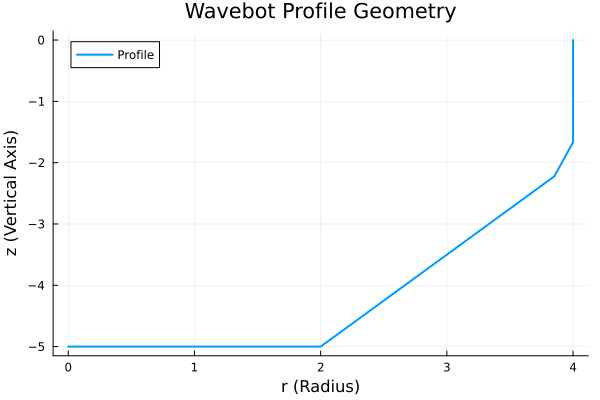

In [2]:
# define wavebot profile
function profile_points(r1,r2,d1,d2)

    # nonhorizontal portion
    function radial_profile(z,r1,r2,d1,d2)
        if z>=-d1
            r = r1
        elseif z>=-d2 && z<=-d1
            m = (r1-r2)/(d2-d1)
            b = r1 + (m*d1)
            r = m * z + b
        end
        return r        
    end
    z_vals1 = range(-d2, stop=0.0, length=10)
    r_vals1 = radial_profile.(z_vals1,r1,r2,d1,d2)

    # horizontal portion
    num_points_h = 3
    z_vals2 = - ones(num_points_h) * d2
    r_vals2 = range(r2, stop=0.0, length=num_points_h)

    # concatinate
    r_vals = vcat(r_vals2,r_vals1)
    z_vals = vcat(z_vals2,z_vals1)

    return r_vals, z_vals
end

r1 = 4.0
r2 = 2.0

d1 = 2.0
d2 = 5.0



(r_vals, z_vals) = profile_points(r1,r2,d1,d2)


plot(r_vals, z_vals,
     xlabel="r (Radius)",
     ylabel="z (Vertical Axis)",  
     title="Wavebot Profile Geometry",
     label="Profile",
     lw=2, 
     grid=true)


In [3]:
r1 = 4.0
r2 = 2.0
d1 = 2.0
d2 = 5.0

profile_points(r1,r2,d1,d2)

([2.0, 1.0, 0.0, 2.0, 2.3703703703703702, 2.7407407407407405, 3.1111111111111107, 3.4814814814814814, 3.8518518518518516, 4.0, 4.0, 4.0, 4.0], [-5.0, -5.0, -5.0, -5.0, -4.444444444444445, -3.888888888888889, -3.3333333333333335, -2.7777777777777777, -2.2222222222222223, -1.6666666666666667, -1.1111111111111112, -0.5555555555555556, 0.0])

In [4]:


(r_vals, z_vals) = profile_points(r1,r2,d1,d2)
# 3D points
x_vals = r_vals
y_vals = zeros(length(r_vals)) # A column of zeros
z_vals = z_vals
pts= np.array(hcat(x_vals, y_vals, z_vals))

# make cpt mesh
wavebot_cpt_mesh = cpt.AxialSymmetricMesh.from_profile(pts,nphi=5)

# make mh mesh
wavebot_mh_mesh = Mesh(wavebot_cpt_mesh)


Mesh([0.0 0.0 -5.0; 0.30901699437494745 0.9510565162951535 -5.0; … ; 1.2360679774997885 -3.8042260651806146 -0.5555555555555556; 1.2360679774997885 -3.8042260651806146 0.0], [2 1 6 13; 0 6 1 0; … ; 102 103 113 112; 103 104 114 113], [1.0181243289582926 0.7397106237851194 -4.999999999999999; 0.4363389981249825 0.31701883876505116 -5.0; … ; 2.6180339887498945 -1.902113032590308 -0.8333333333333334; 2.6180339887498945 -1.902113032590308 -0.2777777777777778], [0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.8090169943749473 -0.5877852522924735 0.0; 0.8090169943749473 -0.5877852522924735 0.0], [1.4265847744427302, 0.47552825814757677, 1.902113032590307, 1.621472135881071, 1.8962979216236264, 2.1711237073661795, 2.4459494931087358, 2.7207752788512884, 2.6229908737970735, 2.612378899077658  …  1.902113032590307, 1.6214721358810706, 1.8962979216236264, 2.17112370736618, 2.4459494931087367, 2.7207752788512884, 2.6229908737970735, 2.612378899077658, 2.612378899077658, 2.612378899077658], [1.229329752476598, 0.6

In [5]:
function cptMesh(r1,r2,d1,d2)
    # r1 = 4.0
    # r2 = 2.0
    # d1 = 2.0
    # d2 = 5.0
    (r_vals, z_vals) = profile_points(r1,r2,d1,d2)

    # 3D points
    x_vals = r_vals
    y_vals = zeros(length(r_vals)) # A column of zeros
    z_vals = z_vals
    pts= np.array(hcat(x_vals, y_vals, z_vals))

    # make cpt mesh
    cptmesh = cpt.AxialSymmetricMesh.from_profile(pts,nphi=5)
    return cptmesh.keep_immersed_part(inplace=true)
end


cptMesh (generic function with 1 method)

In [6]:
cptMesh(r1,r2,d1,d2)

PyObject AxialSymmetricMesh(Mesh(vertices=[[... 23 vertices ...]], faces=[[... 12 faces ...]], name="slice_of_axisymmetric_mesh"), axis=Axis(vector=[0. 0. 1.], point=[0. 0. 0.]), nb_repetitions=4, name="axisymmetric_mesh")

In [ ]:
# Functions for generating input to MarineHydro Mesh struct 
function get_mesh_sizes(r1,r2,d1,d2) 
    cptmesh = cptMesh(r1,r2,d1,d2)
    return cptmesh.nb_faces, cptmesh.nb_vertices
end
function get_vertices(r1,r2,d1,d2)
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.vertices)
end
function get_centers(r1,r2,d1,d2)
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.faces_centers)
end
function get_normals(r1,r2,d1,d2)
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.faces_normals)
end
function get_radii(r1,r2,d1,d2) 
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.faces_radiuses)
end
function get_areas(r1,r2,d1,d2) 
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.faces_areas)
end
function get_faces(r1,r2,d1,d2) 
    cptmesh = cptMesh(r1,r2,d1,d2)
    return reduce(vcat,cptmesh.faces)
end

function ∂J_arg_fd(f, args, i; h=1e-5)
    args_plus = collect(args)
    args_minus = collect(args)
    
    args_plus[i] += h
    args_minus[i] -= h
    
    return (f(args_plus...) .- f(args_minus...)) ./ (2*h)
end

function ChainRulesCore.rrule(::typeof(get_vertices), r1, r2, d1, d2)
    y = get_vertices(r1, r2, d1, d2)
    args = (r1, r2, d1, d2)
    function f_pullback(dy)
        df = NoTangent()  # No gradient w.r.t the function

        # Calculate partials for each input
        dv_dr1 = ∂J_arg_fd(get_vertices, args, 1)
        dv_dr2 = ∂J_arg_fd(get_vertices, args, 2)
        dv_dd1 = ∂J_arg_fd(get_vertices, args, 3)
        dv_dd2 = ∂J_arg_fd(get_vertices, args, 4)

        # Calculate pullbacks
        dr1 = dv_dr1' * dy
        dr2 = dv_dr2' * dy
        dd1 = dv_dd1' * dy
        dd2 = dv_dd2' * dy
        
        return (df, dr1, dr2, dd1, dd2)  
    end    
    return y, f_pullback
end

function ChainRulesCore.rrule(::typeof(get_centers), r1, r2, d1, d2)
    y = get_centers(r1, r2, d1, d2)
    args = (r1, r2, d1, d2)
    function f_pullback(dy)
        df = NoTangent()  # No gradient w.r.t the function

        # Calculate partials for each input
        dv_dr1 = ∂J_arg_fd(get_centers, args, 1)
        dv_dr2 = ∂J_arg_fd(get_centers, args, 2)
        dv_dd1 = ∂J_arg_fd(get_centers, args, 3)
        dv_dd2 = ∂J_arg_fd(get_centers, args, 4)

        # Calculate pullbacks
        dr1 = dv_dr1' * dy
        dr2 = dv_dr2' * dy
        dd1 = dv_dd1' * dy
        dd2 = dv_dd2' * dy
        
        return (df, dr1, dr2, dd1, dd2)  
    end    
    return y, f_pullback
end

function ChainRulesCore.rrule(::typeof(get_normals), r1, r2, d1, d2)
    y = get_normals(r1, r2, d1, d2)
    args = (r1, r2, d1, d2)
    function f_pullback(dy)
        df = NoTangent()  # No gradient w.r.t the function

        # Calculate partials for each input
        dv_dr1 = ∂J_arg_fd(get_normals, args, 1)
        dv_dr2 = ∂J_arg_fd(get_normals, args, 2)
        dv_dd1 = ∂J_arg_fd(get_normals, args, 3)
        dv_dd2 = ∂J_arg_fd(get_normals, args, 4)

        # Calculate pullbacks
        dr1 = dv_dr1' * dy
        dr2 = dv_dr2' * dy
        dd1 = dv_dd1' * dy
        dd2 = dv_dd2' * dy
        
        return (df, dr1, dr2, dd1, dd2)  
    end    
    return y, f_pullback
end

function ChainRulesCore.rrule(::typeof(get_radii), r1, r2, d1, d2)
    y = get_radii(r1, r2, d1, d2)
    args = (r1, r2, d1, d2)
    function f_pullback(dy)
        df = NoTangent()  # No gradient w.r.t the function

        # Calculate partials for each input
        dv_dr1 = ∂J_arg_fd(get_radii, args, 1)
        dv_dr2 = ∂J_arg_fd(get_radii, args, 2)
        dv_dd1 = ∂J_arg_fd(get_radii, args, 3)
        dv_dd2 = ∂J_arg_fd(get_radii, args, 4)

        # Calculate pullbacks
        dr1 = dv_dr1' * dy
        dr2 = dv_dr2' * dy
        dd1 = dv_dd1' * dy
        dd2 = dv_dd2' * dy
        
        return (df, dr1, dr2, dd1, dd2)  
    end    
    return y, f_pullback
end

function ChainRulesCore.rrule(::typeof(get_areas), r1, r2, d1, d2)
    y = get_areas(r1, r2, d1, d2)
    args = (r1, r2, d1, d2)
    function f_pullback(dy)
        df = NoTangent()  # No gradient w.r.t the function

        # Calculate partials for each input
        dv_dr1 = ∂J_arg_fd(get_areas, args, 1)
        dv_dr2 = ∂J_arg_fd(get_areas, args, 2)
        dv_dd1 = ∂J_arg_fd(get_areas, args, 3)
        dv_dd2 = ∂J_arg_fd(get_areas, args, 4)

        # Calculate pullbacks
        dr1 = dv_dr1' * dy
        dr2 = dv_dr2' * dy
        dd1 = dv_dd1' * dy
        dd2 = dv_dd2' * dy
        
        return (df, dr1, dr2, dd1, dd2)  
    end    
    return y, f_pullback
end


# double check this one
function ChainRulesCore.rrule(::typeof(get_faces), r1, r2, d1, d2)
    y = get_faces(r1, r2, d1, d2)
    return y, _ -> (NoTangent(), NoTangent(), NoTangent(), NoTangent(), NoTangent())
end





function differentiableMesh(r1, r2, d1, d2)
    nf,nv = Zygote.@ignore get_mesh_sizes(r1, r2, d1, d2) #hack..need to know how many first to reshape
    vertices = reshape(get_vertices(r1, r2, d1, d2),(nv,3))
    faces =  reshape(get_faces(r1, r2, d1, d2),(nf,4))
    centers = reshape(get_centers(r1, r2, d1, d2),(nf,3))
    normals = reshape(get_normals(r1, r2, d1, d2),(nf,3))
    areas = get_areas(r1, r2, d1, d2)
    radii = get_radii(r1, r2, d1, d2)
    nvertices = size(vertices,1)
    nfaces = size(centers,1)
    return Mesh(vertices,faces,centers,normals,areas,radii,nvertices,nfaces)
end



differentiableMesh (generic function with 1 method)

In [8]:
differentiableMesh(r1, r2, d1, d2)

Mesh([0.0 0.0 -5.0; 0.30901699437494745 0.9510565162951535 -5.0; … ; 1.2360679774997885 -3.8042260651806146 -0.5555555555555556; 1.2360679774997885 -3.8042260651806146 0.0], [2 1 6 13; 0 6 1 0; … ; 102 103 113 112; 103 104 114 113], [1.0181243289582926 0.7397106237851194 -4.999999999999999; 0.4363389981249825 0.31701883876505116 -5.0; … ; 2.6180339887498945 -1.902113032590308 -0.8333333333333334; 2.6180339887498945 -1.902113032590308 -0.2777777777777778], [0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.8090169943749473 -0.5877852522924735 0.0; 0.8090169943749473 -0.5877852522924735 0.0], [1.4265847744427302, 0.47552825814757677, 1.902113032590307, 1.621472135881071, 1.8962979216236264, 2.1711237073661795, 2.4459494931087358, 2.7207752788512884, 2.6229908737970735, 2.612378899077658  …  1.902113032590307, 1.6214721358810706, 1.8962979216236264, 2.17112370736618, 2.4459494931087367, 2.7207752788512884, 2.6229908737970735, 2.612378899077658, 2.612378899077658, 2.612378899077658], [1.229329752476598, 0.6

In [9]:
MHmesh = differentiableMesh(r1, r2, d1, d2)
omega = 0.3
dof = [0,0,1]
AddedMass = calculate_radiation_forces(MHmesh,dof,omega)[1]

41462.00566460117

In [10]:
# make functions for hydrodynamic coefficinets

# Hydrostatics
function hydrostatic_results(r1, r2, d1, d2)
    rho_w = 1025 # density of fluid [kg/m^3]
    g = 9.81 # acceleration due to gravity [m/s^2]
    K = rho_w * g * pi * r1^2 # hydrostatic stiffness [kg/s^2]
    M = rho_w * (pi * r1^2 * d1 + (pi/3) * (d2-d1) * (r1^2 + r1*r2 + r2^2)) # mass of body [kg]
    return [M, K]
end
function hyd_sta_prob(r1, r2, d1, d2)
    j_hydrostatic_results_AD_raw = Zygote.withjacobian(hydrostatic_results,r1, r2, d1, d2) # first row is real pert and second row is imag part
    mass_val = j_hydrostatic_results_AD_raw.val[1]
    mass_grad = hcat(j_hydrostatic_results_AD_raw.grad ...)[1,:]
    hydrostatic_stiffness_val = j_hydrostatic_results_AD_raw.val[2]
    hydrostatic_stiffness_grad = hcat(j_hydrostatic_results_AD_raw.grad ...)[2,:]
    return mass_val, mass_grad, hydrostatic_stiffness_val, hydrostatic_stiffness_grad  
end

# Radiation
function radiation_program(r1, r2, d1, d2, omega, dof) 
    mesh = differentiableMesh(r1, r2, d1, d2) #fd
    A, B = calculate_radiation_forces(mesh,dof,omega)
    return [A, B]
end
function rad_prob(r1, r2, d1, d2, omega, dof)
    radiation_results(r1, r2, d1, d2) = radiation_program(r1, r2, d1, d2, omega, dof)
    j_radiation_results_AD_raw = Zygote.withjacobian(radiation_results,r1, r2, d1, d2) # first row is added mass and second row is damping
    added_mass_val = j_radiation_results_AD_raw.val[1]
    added_mass_grad = hcat(j_radiation_results_AD_raw.grad ...)[1,:]
    damping_val = j_radiation_results_AD_raw.val[2]
    damping_grad = hcat(j_radiation_results_AD_raw.grad ...)[2,:]
    return added_mass_val, added_mass_grad, damping_val, damping_grad 
end

# Diffraction
function diffraction_program(r1, r2, d1, d2, omega, dof) 
    mesh = differentiableMesh(r1, r2, d1, d2) #fd
    F_D = DiffractionForce(mesh,omega,dof)
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    F_ex = F_D + F_FK
    return [real(F_ex),imag(F_ex)]
end
function diff_prob(r1, r2, d1, d2, omega, dof)
    diffraction_results(r1, r2, d1, d2)  = diffraction_program(r1, r2, d1, d2, omega, dof)
    j_diffraction_results_AD_raw = Zygote.withjacobian(diffraction_results,r1, r2, d1, d2) # first row is real pert and second row is imag part
    real_excitation_force_val = j_diffraction_results_AD_raw.val[1]
    real_excitation_force_grad = hcat(j_diffraction_results_AD_raw.grad ...)[1,:]
    imag_excitation_force_val = j_diffraction_results_AD_raw.val[2]
    imag_excitation_force_grad = hcat(j_diffraction_results_AD_raw.grad ...)[2,:]
    return real_excitation_force_val, real_excitation_force_grad, imag_excitation_force_val, imag_excitation_force_grad 
end

# Everything
function compute_all_hydrodynamic_coefficinets_vals_and_grads(r1, r2, d1, d2, omegas)

    # Hydrostatic problem (not frequency dependent)
    mass_val, mass_grad, hydrostatic_stiffness_val, hydrostatic_stiffness_grad  = hyd_sta_prob(r1, r2, d1, d2)
    dof = [0.0,0.0,1.0]

    # Radiation and diffraction problems
    n_omega = length(omegas)
    results = Vector{Any}(undef, n_omega)

    @threads for i in 1:n_omega
        ω = omegas[i]    
        am_v, am_g, dmp_v, dmp_g = rad_prob(r1, r2, d1, d2, ω, dof)
        re_v, re_g, im_v, im_g   = diff_prob(r1, r2, d1, d2, ω, dof)
  
        results[i] = (
            omega = ω,
            added_mass = (val = am_v, grad = am_g),
            damping    = (val = dmp_v, grad = dmp_g),
            force_real = (val = re_v, grad = re_g),
            force_imag = (val = im_v, grad = im_g)
        )
    end
end

compute_all_hydrodynamic_coefficinets_vals_and_grads (generic function with 1 method)

In [ ]:
# omegas = range(start=0.005,stop=0.3,length=10)
# results = compute_all_hydrodynamic_coefficinets_vals_and_grads(r1, r2, d1, d2, omegas)

In [ ]:
# Try mooncak and forwarddiff for derivatives wrt omega 



In [12]:
# j_radiation_results_AD_raw = Zygote.withjacobian(radiation_results,r1, r2, d1, d2) # first row is added mass and second row is damping
# added_mass_val = j_radiation_results_AD_raw.val[1]
# added_mass_grad = hcat(j_radiation_results_AD_raw.grad ...)[1,:]
# damping_val = j_radiation_results_AD_raw.val[2]
# damping_grad = hcat(j_radiation_results_AD_raw.grad ...)[2,:]

In [13]:
# j_diffraction_results_AD_raw = Zygote.withjacobian(diffraction_results,r1, r2, d1, d2) # first row is real pert and second row is imag part
# real_excitation_force_val = j_diffraction_results_AD_raw.val[1]
# real_excitation_force_grad = hcat(j_diffraction_results_AD_raw.grad ...)[1,:]
# imag_excitation_force_val = j_diffraction_results_AD_raw.val[2]
# imag_excitation_force_grad = hcat(j_diffraction_results_AD_raw.grad ...)[2,:]

In [14]:
# j_hydrostatic_results_AD_raw = Zygote.withjacobian(hydrostatic_results,r1, r2, d1, d2) # first row is real pert and second row is imag part
# mass_val = j_hydrostatic_results_AD_raw.val[1]
# mass_grad = hcat(j_hydrostatic_results_AD_raw.grad ...)[1,:]
# hydrostatic_stiffness_val = j_hydrostatic_results_AD_raw.val[2]
# hydrostatic_stiffness_grad = hcat(j_hydrostatic_results_AD_raw.grad ...)[2,:]

In [15]:
# TRy moon cake

In [16]:
# compute using fd
# using FiniteDifferences
# fdm = central_fdm(5, 1)

# # radiation prob
# radiation_results_wrapped(x) = radiation_results(x[1], x[2], x[3], x[4])
# j_radiation_results_FD_raw = FiniteDifferences.jacobian(fdm, radiation_results_wrapped, [r1, r2, d1, d2])
# j_radiation_results_FD = j_radiation_results_FD_raw[1]

# # diffraction prob
# diffraction_results_wrapped(x) = diffraction_results(x[1], x[2], x[3], x[4])
# j_diffraction_results_FD_raw = FiniteDifferences.jacobian(fdm, diffraction_results_wrapped, [r1, r2, d1, d2])
# j_diffraction_results_FD = j_diffraction_results_FD_raw[1]

# # hydrostatic prob
# hydrostatic_results_wrapped(x) = hydrostatic_results(x[1], x[2], x[3], x[4])
# j_hydrostatic_results_FD_raw = FiniteDifferences.jacobian(fdm, hydrostatic_results_wrapped, [r1, r2, d1, d2])
# j_hydrostatic_results_FD = j_hydrostatic_results_FD_raw[1]


In [17]:
# compare sensitivities
# using Test
# @testset "Sensitivities of hydro coeffs wrt wavebot geometric variables" begin
#     @testset "Sensitivities for radiation problem" begin
#         @test j_radiation_results_AD ≈ j_radiation_results_FD atol=1e-6 rtol=1e-6
#     end
#     @testset "Sensitivities for diffraction problem" begin
#         @test j_diffraction_results_AD ≈ j_diffraction_results_FD atol=1e-6 rtol=1e-6
#     end
#     @testset "Sensitivities for hydrostatic problem" begin
#         @test j_hydrostatic_results_AD ≈ j_hydrostatic_results_FD atol=1e-6 rtol=1e-6
#     end
# end